In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mpl_toolkits
import geopandas as gpd

from matplotlib.collections import PatchCollection
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Polygon

import os
# set the directory to the main in the branch
os.chdir('/n/home10/erolf/tree_mapping' )
from experiment_utils import  get_site_splits

import pandas as pd

import rasterio
from shapely.ops import unary_union


In [3]:
def find_sentinel_tile(site_id):
    s2_dir_10m_this_sight = f'data/int/sentinel/sentinel_by_site_32736_10m/{site_id}'
    band_tifs = [x for x in os.listdir(s2_dir_10m_this_sight) if 'TCI' in x]
    return os.path.join(s2_dir_10m_this_sight,band_tifs[0])
    
def show_site_data(ax, site_id):
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(ax)
    ax2 = divider.append_axes("right", size="100%", pad=0.05)
    fig1 = ax.get_figure()
    fig1.add_axes(ax2)

    with rasterio.open(f'data/int/lidar/lidar_by_site_32736_10m/{site_id}/{site_id}_CHM_10m.tif', 'r') as f:
        chm = f.read()[0]
    ax.imshow(chm, cmap='Greens', vmin=0,vmax=15, interpolation='none')
    
    with rasterio.open(find_sentinel_tile(site_id), 'r') as f:
        img = f.read()
    ax2.imshow(img.transpose(1,2,0), interpolation='none')
    
    for axis in [ax,ax2]:
        axis.axis('off')

In [4]:
# condense shapefile to explain split 1
    
all_sites = gpd.read_file('data/AllProcessedSites_2022-11-03/AllProcessedSites_Server_GDrive_Updated20221103_ManualEdits_V2.shp')

all_sites = all_sites.replace(
    {'KaringaniSunguloDevNode': 'KaringaniSungoloDevNode',
    'KaringaniDevNodeSouthSouth': 'KaringaniSouthSouthDevNode',
     'KaringaniMbilu': 'Mbilu'
    }
)

Karingani_border = gpd.read_file('data/karingani_shapefile/KaGRBndLnUTM36s.shp').to_crs(all_sites.crs)


In [5]:
split_seed = 10
split_number = 0
splits = get_site_splits(split_seed)[split_number]

In [6]:
sites_gdf = gpd.GeoDataFrame()
for split, sites in splits.items():
    for site in sites:
        row = all_sites.loc[all_sites['site'] == site, :].copy()
        row[f'split_{split_number}'] = split.split('_')[0]
        sites_gdf = pd.concat((sites_gdf, row))
    
splits_shapefile = os.path.join('data/summary_data',f'all_karingani_sites_split_{split_number}')
sites_gdf.to_file(splits_shapefile, driver='ESRI Shapefile')


In [7]:
# GEDI data goes from 51.6S to 51.6N
gedi_extent_lat = [-51.6, 51.6]

In [8]:
def llbox_to_polygon(lon1, lat1, lon2, lat2, full_globe):
    lats = [ lat1, lat2, lat2, lat1]
    lons = [ lon1, lon1, lon2, lon2]
    
    x, y = full_globe( lons, lats )
    xy = np.vstack([x,y]).T
    poly = Polygon( xy, fill=False,  )
    
    return poly

In [9]:
site_id_train = splits['train_sites'][0]
site_id_val = splits['val_sites'][0]
site_id_test = splits['test_sites'][1]

Text(0.5, 1.0, '6 test sites')

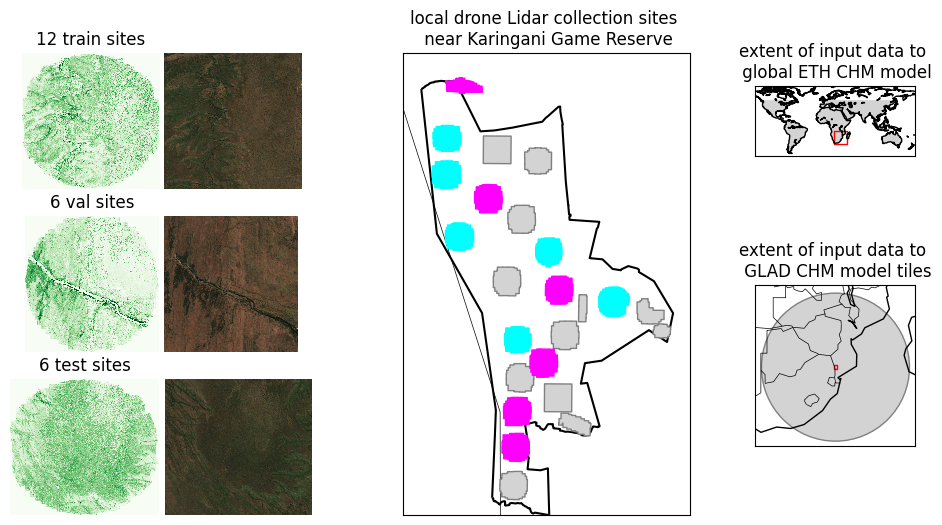

In [11]:
# fig, ax = plt.subplots(2,1, figsize=(10,10))
# ax_eth, ax_glad = ax

fig = plt.figure(figsize=(12,6))

ax_glad = plt.subplot2grid((3,5), (1,4), rowspan=2)
ax_eth = plt.subplot2grid((3,5), (0,4))
ax_ours = plt.subplot2grid((3,5), (0,2), rowspan=3, colspan=2)
ax_trainsite = plt.subplot2grid((3,5), (0,0), colspan=2)
ax_valsite = plt.subplot2grid((3,5), (1,0),  colspan=2)
ax_testsite = plt.subplot2grid((3,5), (2,0), colspan=2)


# draw the full globe to plot the gedi data that goes in to the ETH model
map_gedi = Basemap(ax=ax_eth, projection='cyl',lon_0=0,
                   llcrnrlon=-140, llcrnrlat=gedi_extent_lat[0], urcrnrlon=180,urcrnrlat=gedi_extent_lat[1])
map_gedi.fillcontinents(color='lightgrey',lake_color='white')

full_globe = Basemap(ax=ax_eth, projection='cyl',llcrnrlon=-140, llcrnrlat=-60, urcrnrlon=180,urcrnrlat=80)
full_globe.drawcoastlines()

# add the box from the GLAD extent to the ETH map
GLAD_radius = 12
llbox_GLAD_cells = [31, -25, 33, -23]
ll_box_GLAD_training_range = np.array(llbox_GLAD_cells) + np.array([-GLAD_radius, -GLAD_radius, GLAD_radius, GLAD_radius])
GLAD_extent_poly = [llbox_to_polygon(*ll_box_GLAD_training_range, full_globe)]
ax_eth.add_collection(PatchCollection(GLAD_extent_poly, facecolor="none", edgecolor='red', linewidths=1))

map_glad_extent = Basemap(ax=ax_glad, 
                          llcrnrlon=ll_box_GLAD_training_range[0], llcrnrlat=ll_box_GLAD_training_range[1], 
                          urcrnrlon=ll_box_GLAD_training_range[2],urcrnrlat=ll_box_GLAD_training_range[3])
map_glad_extent.drawcountries()
map_glad_extent.drawcoastlines()

lats1 = [ -25, -24, -24, -25 ]
lats2 = [ -24, -23, -23, -24 ]
lons1 = [ 31, 31, 32, 32 ]
lons2 = [ 32, 32, 33, 33 ]

lat1_box_ours, lat2_box_ours = -24.62, -23.9
lon1_box_ours, lon2_box_ours = 31.85, 32.34

map_ours = Basemap(ax=ax_ours, llcrnrlon=lon1_box_ours, llcrnrlat=lat1_box_ours, urcrnrlon=lon2_box_ours,urcrnrlat=lat2_box_ours)
map_ours.drawcountries()
map_ours.drawcoastlines()

# read the shapefile
map_ours.readshapefile(os.path.join(splits_shapefile,f'all_karingani_sites_split_{split_number}'),'splits', drawbounds=False)
train_patches, val_patches, test_patches = [], [], []
for info, shape in zip(map_ours.splits_info, map_ours.splits):
    if info[f'split_{split_number}'] == 'train':
        train_patches.append(Polygon(np.array(shape)))
    elif info[f'split_{split_number}'] == 'val':
        val_patches.append(Polygon(np.array(shape)))
    elif info[f'split_{split_number}'] == 'test':
        test_patches.append(Polygon(np.array(shape)))
                           
ax_ours.add_collection(PatchCollection(train_patches, facecolor= 'lightgrey', edgecolor='grey', linewidths=1., zorder=2))
ax_ours.add_collection(PatchCollection(val_patches, facecolor= 'magenta', edgecolor='magenta', linewidths=1., zorder=2))
ax_ours.add_collection(PatchCollection(test_patches, facecolor= 'cyan', edgecolor='cyan', linewidths=1., zorder=2))
Karingani_border.plot(ax=ax_ours, edgecolor='black', zorder=0)


#border =  [Polygon(x) for x in Karingani_border.geometry]
#ax_ours.add_collection(PatchCollection(border[:1], facecolor='none', edgecolor='Black'))

#border = unary_union(Karingani_border.geometry)

our_extent_poly = [llbox_to_polygon(lon1_box_ours, lat1_box_ours, lon2_box_ours, lat2_box_ours, full_globe)]


x,y=map_glad_extent(  (lon1_box_ours+lon2_box_ours)/2, (lat1_box_ours+lat2_box_ours)/2,)
x2,y2 = map_glad_extent( (lon1_box_ours+lon2_box_ours)/2, (lat1_box_ours+lat2_box_ours)/2+12)
circle1 = plt.Circle((x, y), y2-y, facecolor= 'lightgrey', edgecolor='grey')
ax_glad.add_patch(circle1, )

ax_glad.add_collection(PatchCollection(our_extent_poly, facecolor="none", edgecolor='red', linewidths=1))

ax_eth.set_title('extent of input data to \n global ETH CHM model')
ax_glad.set_title('extent of input data to \n GLAD CHM model tiles')
ax_ours.set_title('local drone Lidar collection sites \n near Karingani Game Reserve')

show_site_data(ax_trainsite, site_id_train)
show_site_data(ax_testsite, site_id_test)
show_site_data(ax_valsite, site_id_val)

ax_trainsite.set_title('12 train sites')
ax_valsite.set_title('6 val sites')
ax_testsite.set_title('6 test sites')

#plt.show()

#plt.savefig('figures/karingani_data_fig.pdf',format='pdf', bbox_inches='tight')